# Run FF-SIMS Fit

Self-contained config-native HERA/ARES runner. This notebook declares the FF-SIMS model inputs directly with `lenscluster.config` dataclasses. No Lenstool par file is used.

Notebook runs use notebook-safe `tqdm` progress bars. Terminal runs through `run.xsh` keep the Rich progress UI. Keep `RuntimeConfig(quiet=False)` if you want notebook progress bars.

## 1. Environment Setup

Set the working directory to the repository root, choose the FF-SIMS cluster, and fix the number of CPU devices used by JAX. Run this cell before importing `lenscluster` so the JAX device count is set early.


In [1]:
import os
import sys
from pathlib import Path

repo_root = Path.cwd()
if not (repo_root / "src" / "lenscluster").exists():
    repo_root = next(
        path for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "src" / "lenscluster").exists()
    )
os.chdir(repo_root)
sys.path.insert(0, str(repo_root))

CLUSTER = "HERA"  # or "ARES"
OUTPUT_DIR_LABEL = os.environ.get("LENSCLUSTER_OUTPUT_LABEL", "jun23a_notebook_config")

# Keep JAX CPU devices and NUTS chains fixed and matched.
cores = 4
os.environ["JAX_NUM_CPU_DEVICES"] = str(cores)
print(f"repo={repo_root}")
print(f"cluster={CLUSTER} cores={cores}")

repo=/Users/colinburke/research/lenscluster
cluster=HERA cores=4


## 2. Imports and Display Defaults

Import the config dataclasses, planner, and runner used by the config-native workflow. The RGB display settings are only used for optional image cutout plots.


In [ ]:
from lenscluster.config import (
    CosmologyConfig,
    DPIEHaloConfig,
    ImageCatalogCutoutConfig,
    ImageConstraintsConfig,
    ImageDiagnosticsConfig,
    IndependentMemberHaloConfig,
    LensClusterSolverConfig,
    LensModelConfig,
    LikelihoodConfig,
    MemberPopulationConfig,
    MemberSelectionConfig,
    PerturbationDiscoveryConfig,
    PriorConfig,
    RGBDisplayConfig,
    ReferenceFrameConfig,
    RunPathsConfig,
    RuntimeConfig,
    ScalingModelConfig,
    StageScheduleConfig,
    TruthRecoveryConfig,
    WorkflowConfig,
)
from lenscluster.planning import compile_run_plan
from lenscluster.runner import LensClusterRunner

FF_RGB_BANDS = ("F435W", "F606W", "F814W")
FF_RGB_DISPLAY = RGBDisplayConfig(
    q=6.8,
    stretch=0.0158,
    minimum=0.00105,
    red_gain=0.62,
    green_gain=0.78,
    blue_gain=3.65,
)

## 3. Cluster Inputs

Define the available mock clusters and their data files, lens halos, member-galaxy population, truth maps, and priors. Change `CLUSTER` in the setup cell to switch between these entries.


In [ ]:
FF_SIMS_CLUSTERS = {
    "ARES": {
        "cluster_key": "ares",
        "output_dir": f"results/{OUTPUT_DIR_LABEL}/ares",
        "image_catalog": "data/ff_sims/ares/ares_obs_arcs.cat",
        "member_catalog": "data/ff_sims/ares/ares_cluster_members_potfile.cat",
        "cosmology": CosmologyConfig(H0=70.4, Om0=0.272, Ode0=0.728),
        "z_lens": 0.5,
        "halos": (
            DPIEHaloConfig(
                id="1",
                x_centre=20.0,
                y_centre=-32.0,
                ellipticite=0.3,
                angle_pos=0.0,
                core_radius_kpc=20.0,
                cut_radius_kpc=1500.0,
                v_disp=950.0,
                z_lens=0.5,
                priors={
                    "x_centre": PriorConfig("uniform", lower=15.0, upper=25.0, step=0.5),
                    "y_centre": PriorConfig("uniform", lower=-37.0, upper=-27.0, step=0.5),
                    "ellipticite": PriorConfig("uniform", lower=0.0, upper=0.5, step=0.02),
                    "angle_pos": PriorConfig("uniform", lower=-180.0, upper=180.0, step=1.0),
                    "core_radius_kpc": PriorConfig("uniform", lower=5.0, upper=60.0, step=1.0),
                    "v_disp": PriorConfig("truncated_normal", mean=950.0, std=250.0, lower=500.0, upper=1800.0),
                },
            ),
            DPIEHaloConfig(
                id="2",
                x_centre=-40.0,
                y_centre=40.0,
                ellipticite=0.3,
                angle_pos=0.0,
                core_radius_kpc=20.0,
                cut_radius_kpc=1500.0,
                v_disp=950.0,
                z_lens=0.5,
                priors={
                    "x_centre": PriorConfig("uniform", lower=-45.0, upper=-35.0, step=0.5),
                    "y_centre": PriorConfig("uniform", lower=35.0, upper=45.0, step=0.5),
                    "ellipticite": PriorConfig("uniform", lower=0.0, upper=0.5, step=0.02),
                    "angle_pos": PriorConfig("uniform", lower=-180.0, upper=180.0, step=1.0),
                    "core_radius_kpc": PriorConfig("uniform", lower=5.0, upper=45.0, step=1.0),
                    "v_disp": PriorConfig("truncated_normal", mean=950.0, std=175.0, lower=600.0, upper=1400.0),
                },
            ),
        ),
        "member_population": MemberPopulationConfig(
            id="potfile_1",
            catalog_path="data/ff_sims/ares/ares_cluster_members_potfile.cat",
            mag0=18.5,
            corekpc=0.15,
            sigma=100.0,
            cutkpc=270.0,
            z_lens=0.5,
            sigma_prior=PriorConfig("truncated_normal", mean=100.0, std=15.0, lower=70.0, upper=500.0),
            cutkpc_prior=PriorConfig("truncated_normal", mean=270.0, std=35.0, lower=160.0, upper=800.0),
        ),
        "independent_member_halos": (
            IndependentMemberHaloConfig(population_id="potfile_1", catalog_id="2"),
            IndependentMemberHaloConfig(population_id="potfile_1", catalog_id="3"),
        ),
        "kappa_true_fits": "data/ff_sims/published/ares/kappa_z9_0.fits",
        "gammax_true_fits": "data/ff_sims/published/ares/gammax_z9_0.fits",
        "gammay_true_fits": "data/ff_sims/published/ares/gammay_z9_0.fits",
        "softening_length_kpc": 0.0,
        "softening_length_prior_log_sigma": 0.15,
    },
    "HERA": {
        "cluster_key": "hera",
        "output_dir": f"results/{OUTPUT_DIR_LABEL}/hera",
        "image_catalog": "data/ff_sims/hera/hera_obs_arcs.cat",
        "member_catalog": "data/ff_sims/hera/hera_cluster_members_potfile.cat",
        "cosmology": CosmologyConfig(H0=72.0, Om0=0.24, Ode0=0.76),
        "z_lens": 0.507,
        "halos": (
            DPIEHaloConfig(
                id="1",
                x_centre=19.54080009,
                y_centre=2.37820005,
                ellipticite=0.3,
                angle_pos=30.0,
                core_radius_kpc=8.0,
                cut_radius_kpc=1500.0,
                v_disp=800.0,
                z_lens=0.507,
                priors={
                    "x_centre": PriorConfig("uniform", lower=14.54080009, upper=24.54080009, step=0.5),
                    "y_centre": PriorConfig("uniform", lower=-2.62179995, upper=7.37820005, step=0.5),
                    "ellipticite": PriorConfig("uniform", lower=0.0, upper=0.8, step=0.02),
                    "angle_pos": PriorConfig("uniform", lower=-180.0, upper=180.0, step=1.0),
                    "core_radius_kpc": PriorConfig("uniform", lower=2.0, upper=15.0, step=1.0),
                    "v_disp": PriorConfig("truncated_normal", mean=800.0, std=280.0, lower=100.0, upper=2200.0),
                },
            ),
            DPIEHaloConfig(
                id="2",
                x_centre=0.001,
                y_centre=0.003,
                ellipticite=0.3,
                angle_pos=24.0,
                core_radius_kpc=5.0,
                cut_radius_kpc=1500.0,
                v_disp=700.0,
                z_lens=0.507,
                priors={
                    "x_centre": PriorConfig("uniform", lower=-4.999, upper=5.001, step=0.5),
                    "y_centre": PriorConfig("uniform", lower=-4.997, upper=5.003, step=0.5),
                    "ellipticite": PriorConfig("uniform", lower=0.0, upper=0.8, step=0.02),
                    "angle_pos": PriorConfig("uniform", lower=-180.0, upper=180.0, step=1.0),
                    "core_radius_kpc": PriorConfig("uniform", lower=2.0, upper=15.0, step=1.0),
                    "v_disp": PriorConfig("truncated_normal", mean=700.0, std=245.0, lower=100.0, upper=2200.0),
                },
            ),
        ),
        "member_population": MemberPopulationConfig(
            id="potfile_1",
            catalog_path="data/ff_sims/hera/hera_cluster_members_potfile.cat",
            mag0=19.82,
            corekpc=0.15,
            sigma=96.7,
            cutkpc=33.0,
            z_lens=0.507,
            sigma_prior=PriorConfig("truncated_normal", mean=96.7, std=40.0, lower=30.0, upper=250.0),
            cutkpc_prior=PriorConfig("truncated_normal", mean=33.0, std=25.0, lower=3.0, upper=250.0),
        ),
        "independent_member_halos": (
            IndependentMemberHaloConfig(population_id="potfile_1", catalog_id="1"),
            IndependentMemberHaloConfig(population_id="potfile_1", catalog_id="2"),
        ),
        "kappa_true_fits": "data/ff_sims/published/hera/kappa_z9_0.fits",
        "gammax_true_fits": "data/ff_sims/published/hera/gammax_z9_0.fits",
        "gammay_true_fits": "data/ff_sims/published/hera/gammay_z9_0.fits",
        # HERA uses H0=72 km/s/Mpc, so h=0.72 and 2.3 h^-1 kpc = 3.19 kpc physical.
        "softening_length_kpc": 2.3 / 0.72,
        "softening_length_prior_log_sigma": 0.15,
    },
}

## 4. Build the Solver Config

Create a `LensClusterSolverConfig` for the selected mock cluster. This is the main place to adjust sampler settings, likelihood choices, diagnostics, member selection, and output naming.


In [ ]:
def build_ff_sims_config(cluster: str, *, cores: int) -> LensClusterSolverConfig:
    selected_cluster = cluster.strip().upper()
    if selected_cluster not in FF_SIMS_CLUSTERS:
        raise ValueError(f"cluster must be one of {', '.join(sorted(FF_SIMS_CLUSTERS))}; got {selected_cluster!r}.")
    cluster_config = FF_SIMS_CLUSTERS[selected_cluster]

    perturbation_alpha_tol = 1.0
    perturbation_jacobian_tol = 1.0
    perturbation_top_k = 5

    warmup = 2000
    samples = 500
    max_tree_depth = 8
    mode = "none"
    stage0_likelihood = "source"
    stage1_likelihood = "critical-arc-anisotropic"
    output_dir = (
        f"{cluster_config['output_dir']}_likelihood_{stage1_likelihood}_PD{perturbation_alpha_tol:g}_"
        f"{perturbation_jacobian_tol:g}_T{max_tree_depth}W{warmup}S{samples}"
    )
    run_name = f"{cluster_config['cluster_key']}_S1{stage1_likelihood}_S2{mode}"

    return LensClusterSolverConfig(
        model=LensModelConfig(
            reference=ReferenceFrameConfig(reference=3, ra0_deg=0.0, dec0_deg=0.0),
            cosmology=cluster_config["cosmology"],
            large_halos=cluster_config["halos"],
            independent_member_halos=cluster_config["independent_member_halos"],
            member_populations=(cluster_config["member_population"],),
            image_constraints=ImageConstraintsConfig(catalog_path=cluster_config["image_catalog"], sigma_arcsec=0.5),
        ),
        paths=RunPathsConfig(output_dir=output_dir, run_name=run_name),
        runtime=RuntimeConfig(
            chains=cores,
            resume=False,
            quick_diagnostics=False,
            quiet=False,
            debug_sampler_diagnostics=True,
            numpyro_print_summary=True,
            nuts_chain_method="parallel",
            dense_mass="structured",
            jax_clear_caches_after_svi_refresh=False,
        ),
        workflow=WorkflowConfig(
            fit_mode="sequential",
            stage0_likelihood=stage0_likelihood,
            stage1_likelihood=stage1_likelihood,
            stage2_forward_mode=mode,
            stage1_sampling_engine="refreshing_surrogate_flat",
            stage2_sampling_engine="refreshing_surrogate_flat",
            stage2_fresh_process=True,
            exact_image_diagnostics_stage2=True,
            best_value="maximum-likelihood",
            image_plane_newton_steps=0,
            linearized_beta_prior_sigma_arcsec=3.0,
            source_position_parameterization="prior-whitened",
        ),
        schedule=StageScheduleConfig(
            fit_method=("svi+nuts",),
            refresh_every=(None, 200),
            svi_steps=(1000, 1000),
            warmup=(warmup,),
            samples=(samples,),
            sampling_refresh_runs=(1,),
            max_tree_depth=(max_tree_depth,),
            target_accept=0.8,
            z_bin_efficiency_tol=0.0,
        ),
        members=MemberSelectionConfig(potfile_member_mag_max=(22.0,)),
        perturbation=PerturbationDiscoveryConfig(
            perturbation_discovery_alpha_tol_arcsec=perturbation_alpha_tol,
            perturbation_discovery_jacobian_tol=perturbation_jacobian_tol,
            perturbation_discovery_jacobian_weight=1.0,
            perturbation_discovery_top_k=perturbation_top_k,
        ),
        scaling=ScalingModelConfig(
            independent_scaling_free_log_sigma_tau_prior_median=0.45,
            independent_scaling_free_log_mass_tau_prior_median=0.55,
            independent_scaling_free_log_tau_prior_sigma=0.30,
            potfile_alpha_sigma_prior_mean=0.25,
            potfile_alpha_sigma_prior_std=0.3,
            potfile_alpha_sigma_prior_lower=0.05,
            potfile_alpha_sigma_prior_upper=0.50,
            potfile_gamma_ml_prior_mean=0.20,
            potfile_gamma_ml_prior_std=0.3,
            potfile_gamma_ml_prior_lower=-0.80,
            potfile_gamma_ml_prior_upper=0.80,
            scaling_scatter=True,
            softening_length_kpc=float(cluster_config["softening_length_kpc"]),
            softening_length_prior_log_sigma=float(cluster_config["softening_length_prior_log_sigma"]),
        ),
        likelihood=LikelihoodConfig(
            pos_sigma_arcsec=0.01,
            source_plane_covariance_mode="magnification",
            image_presence_penalty_weight=2.0,
            image_presence_match_radius_arcsec=1.0,
            image_presence_temperature_arcsec=0.5,
            image_plane_scatter_prior="log-uniform",
            image_plane_scatter_floor_arcsec=0.01,
            image_plane_scatter_upper_arcsec=1.0,
        ),
        image_diagnostics=ImageDiagnosticsConfig(
            fit_quality_draws=0,
            exact_image_min_distance_arcsec=0.5,
            exact_image_precision_limit=1.0e-2,
            exact_image_num_iter_max=100,
            exact_image_finder="local-lm-adaptive",
            exact_image_displacement_tol_arcsec=1.0e-4,
            exact_image_identification_tol_arcsec=1.0e-3,
            match_tolerance_arcsec=2.0,
        ),
        truth=TruthRecoveryConfig(
            kappa_true_fits=cluster_config["kappa_true_fits"],
            gammax_true_fits=cluster_config["gammax_true_fits"],
            gammay_true_fits=cluster_config["gammay_true_fits"],
            truth_grid_mode="posterior",
            truth_grid_draws=16,
            truth_grid_size=256,
            caustic_source_redshift=9.0,
        ),
        image_catalog=ImageCatalogCutoutConfig(
            image_dir="data/ff_sims",
            image_scale="auto",
            bands=FF_RGB_BANDS,
            rgb=FF_RGB_DISPLAY,
            mode="fast",
            cutouts=False,
        ),
    )


def preview_plan(plan) -> None:
    print(f"run_name: {plan.output.run_name}")
    print(f"output_dir: {plan.output.output_dir}")
    print(f"chains: {plan.runtime.chains}")
    print("stages:")
    for stage in plan.stages:
        print(f"  - {stage.name}: engine={stage.sampling_engine}, svi_steps={stage.svi_steps}, refresh_every={stage.refresh_every}")

## 5. Compile and Preview the Plan

Compile the high-level config into a concrete run plan. The preview is a sanity check: confirm the output path, run name, stages, and selected independent member halos before starting the fit.


In [ ]:
config = build_ff_sims_config(CLUSTER, cores=cores)
plan = compile_run_plan(config)
preview_plan(plan)
print(f"large_halos={len(config.model.large_halos)} member_populations={len(config.model.member_populations)}")
print(f"independent_member_halos={[item.catalog_id for item in config.model.independent_member_halos]}")

run_name: hera_S1critical-arc_S2none
output_dir: results/jun23a_notebook_config/hera_likelihood_critical-arc_PD1_1_T8W2000S500
chains: 4
stages:
  - stage0_fast_initializer: engine=full_flat, svi_steps=1000, refresh_every=None
  - stage1_backprojected_centroid_fit: engine=refreshing_surrogate_flat, svi_steps=1000, refresh_every=200
large_halos=2 member_populations=1
independent_member_halos=['1', '2']


## 6. Run the Fit

Run the sequential solver. This writes parameter-only HDF5 artifacts under each stage's `artifacts/` directory before generating plots, so the saved samples remain available even if plotting is skipped or interrupted.


In [ ]:
# Uncomment to run the fit. This can take a long time.
result = LensClusterRunner().run(plan)
result

Matplotlib is building the font cache; this may take a moment.


2026-06-24T08:26:29 [main] startup

2026-06-24T08:26:29 [runtime] python=/Users/colinburke/miniforge3/envs/jaxstronomy/bin/python jax_devices=4 
backend=cpu jax_default_device=auto smc_device=auto 
output_dir=results/jun23a_notebook_config/hera_likelihood_critical-arc_PD1_1_T8W2000S500

2026-06-24T08:26:29 [stage] ============================ SEQUENTIAL WORKFLOW =============================

2026-06-24T08:26:29 [stage] run_name=hera_S1critical-arc_S2none stage0=stage0_fast_initializer likelihood=source 
stage1=stage1_backprojected_centroid_fit likelihood=critical-arc stage2=disabled mode=none resume_mode=none

...

2026-06-24T08:52:57 [done] sequential run summary
Sequential Cluster Solver Run Summary
run_name=hera_S1critical-arc_S2none
root_dir=results/jun23a_notebook_config/hera_likelihood_critical-arc_PD1_1_T8W2000S500/hera_S1critical-arc_S2none

Stage Quality Comparison
stage                             fit      likelihood                       sampler      families images 
headline_chi2 headline_dof headline_red point_RMS point_med N_point arc_chi2 arc_dof arc_red N_arc N_arcaware 
N_missing arc_RMS arc_med ESS_min Rhat_max runtime_s
--------------------------------- -------- -------------------------------- ------------ -------- ------ 
------------- ------------ ------------ --------- --------- ------- -------- ------- ------- ----- ---------- 
--------- ------- ------- ------- -------- ---------
stage0_fast_initializer           svi      source                           svi          19       65     na        
-83          na           na        na        0       na       na      na      na    na         na        na      
na      na      na       73.35    
stage1_backprojected_centroid_fit svi+nuts critical-arc-mixture-image-plane numpyro_nuts 19       65     197.6     
31           6.375        0.7848    0.5675    63      186.9    30      6.231   1     63         2         0.7633  
0.5596  2.084   5.284    1328

2026-06-24T08:52:57 [stage] ======================== SEQUENTIAL WORKFLOW COMPLETE ========================

2026-06-24T08:52:57 [stage] run_name=hera_S1critical-arc_S2none

2026-06-24T08:52:57 [stage] sequential end run_name=hera_S1critical-arc_S2none

RunResult(run_name='hera_S1critical-arc_S2none', output_dir=PosixPath('results/jun23a_notebook_config/hera_likelihood_critical-arc_PD1_1_T8W2000S500'), run_dir=PosixPath('results/jun23a_notebook_config/hera_likelihood_critical-arc_PD1_1_T8W2000S500/hera_S1critical-arc_S2none'), completed=True)

## 7. Load Saved Parameter Artifacts

Load the saved `plot_bundle.h5` without rebuilding compiled model code. The quick plots below use only arrays and metadata from the artifact: posterior samples, log probabilities, best-fit values, and parameter names.


In [ ]:
from lenscluster.artifacts import load_parameter_artifact
import matplotlib.pyplot as plt
import numpy as np

run_dir = result.run_dir if "result" in globals() else plan.output.output_dir / plan.output.run_name
artifact = load_parameter_artifact(run_dir)

print(f"loaded: {artifact.path}")
print(f"samples={artifact.samples.shape} parameters={len(artifact.parameter_names)}")

# Pick a compact subset so the notebook stays readable even for large models.
log_prob = np.asarray(artifact.log_prob, dtype=float).reshape(-1)
samples = np.asarray(artifact.samples, dtype=float)
finite_columns = np.where(np.nanstd(samples, axis=0) > 0)[0]
plot_indices = finite_columns[: min(6, len(finite_columns))]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), constrained_layout=True)
axes[0].plot(log_prob, lw=1.0)
axes[0].set_title("Log probability")
axes[0].set_xlabel("sample")
axes[0].set_ylabel("log prob")

if artifact.sample_weights is not None:
    axes[1].hist(np.asarray(artifact.sample_weights).reshape(-1), bins=30, color="0.25")
    axes[1].set_title("Sample weights")
    axes[1].set_xlabel("weight")
else:
    axes[1].axis("off")
    axes[1].text(0.5, 0.5, "No sample weights saved", ha="center", va="center")
plt.show()

if len(plot_indices):
    n = len(plot_indices)
    fig, axes = plt.subplots(n, 2, figsize=(11, max(2.2 * n, 3.5)), constrained_layout=True)
    axes = np.atleast_2d(axes)
    for row, idx in enumerate(plot_indices):
        name = artifact.parameter_names[idx] if idx < len(artifact.parameter_names) else f"theta_{idx}"
        values = samples[:, idx]
        axes[row, 0].plot(values, lw=0.8)
        axes[row, 0].axhline(artifact.best_fit[idx], color="tab:red", lw=1.0, label="best fit")
        axes[row, 0].set_ylabel(name)
        axes[row, 0].set_xlabel("sample")
        if row == 0:
            axes[row, 0].legend(loc="best")

        axes[row, 1].hist(values, bins=35, color="0.35", alpha=0.85)
        axes[row, 1].axvline(artifact.best_fit[idx], color="tab:red", lw=1.0)
        axes[row, 1].set_xlabel(name)
        axes[row, 1].set_ylabel("count")
    plt.show()
else:
    print("No varying parameter columns found to plot.")



loaded: results/jun23a_notebook_config/hera_likelihood_critical-arc_PD1_1_T8W2000S500/hera_S1critical-arc_S2none/stage1_backprojected_centroid_fit/artifacts/plot_bundle.h5
samples=(2000, 57) parameters=57


/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_98371/1023801949.py:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_98371/1023801949.py:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 8. Regenerate Validation and Show Plots

Use `plots_only=True` to reload saved artifacts, recompute validation outputs, and show the key recovery/residual Matplotlib figures inline through the standard plotting API. This does not rerun SVI or NUTS.


Matplotlib is building the font cache; this may take a moment.


2026-06-24T09:33:08 [main] startup

2026-06-24T09:33:08 [runtime] python=/Users/colinburke/miniforge3/envs/jaxstronomy/bin/python jax_devices=4 
backend=cpu jax_default_device=auto smc_device=auto 
output_dir=results/jun23a_notebook_config/hera_likelihood_critical-arc_PD1_1_T8W2000S500

2026-06-24T09:33:08 [stage] =========== PLOTS ONLY: STAGE 1: stage1_backprojected_centroid_fit ===========

2026-06-24T09:33:08 [stage] 
run_dir=results/jun23a_notebook_config/hera_likelihood_critical-arc_PD1_1_T8W2000S500/hera_S1critical-arc_S2none/st
age1_backprojected_centroid_fit

...

plot stages:   0%|          | 0/3 [00:00<?, ?it/s]

run_diagnostics:   0%|          | 0/45 [00:00<?, ?it/s]

image_recovery:   0%|          | 0/20 [00:00<?, ?it/s]

fit quality exact: 0/19 family diagnostics:   0%|          | 0/19 [00:00<?, ?it/s]

draw progress: 0/1 complete:   0%|          | 0/1 [00:00<?, ?it/s]

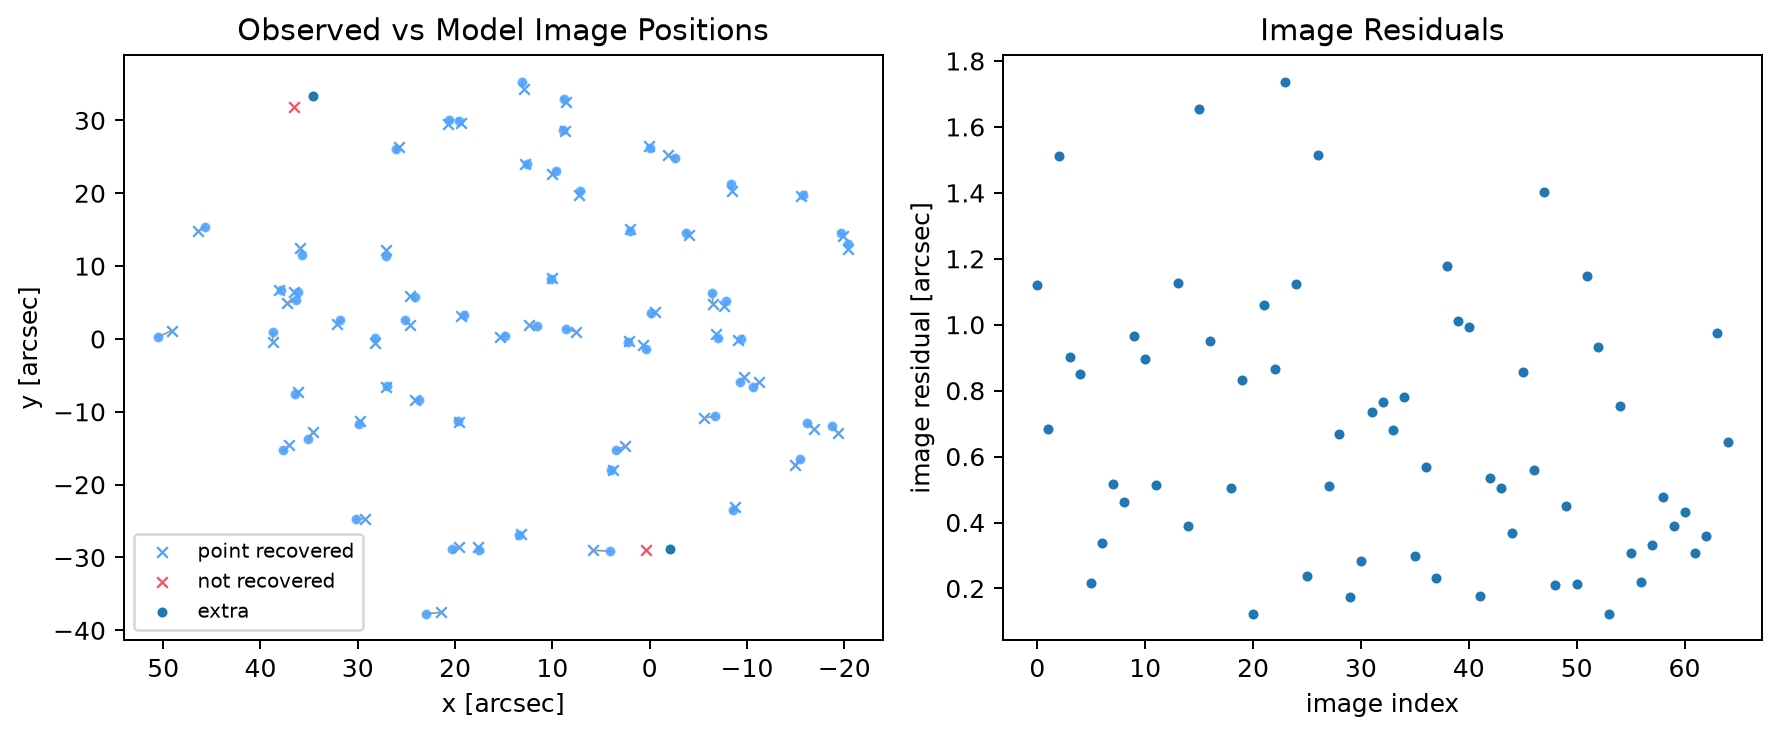

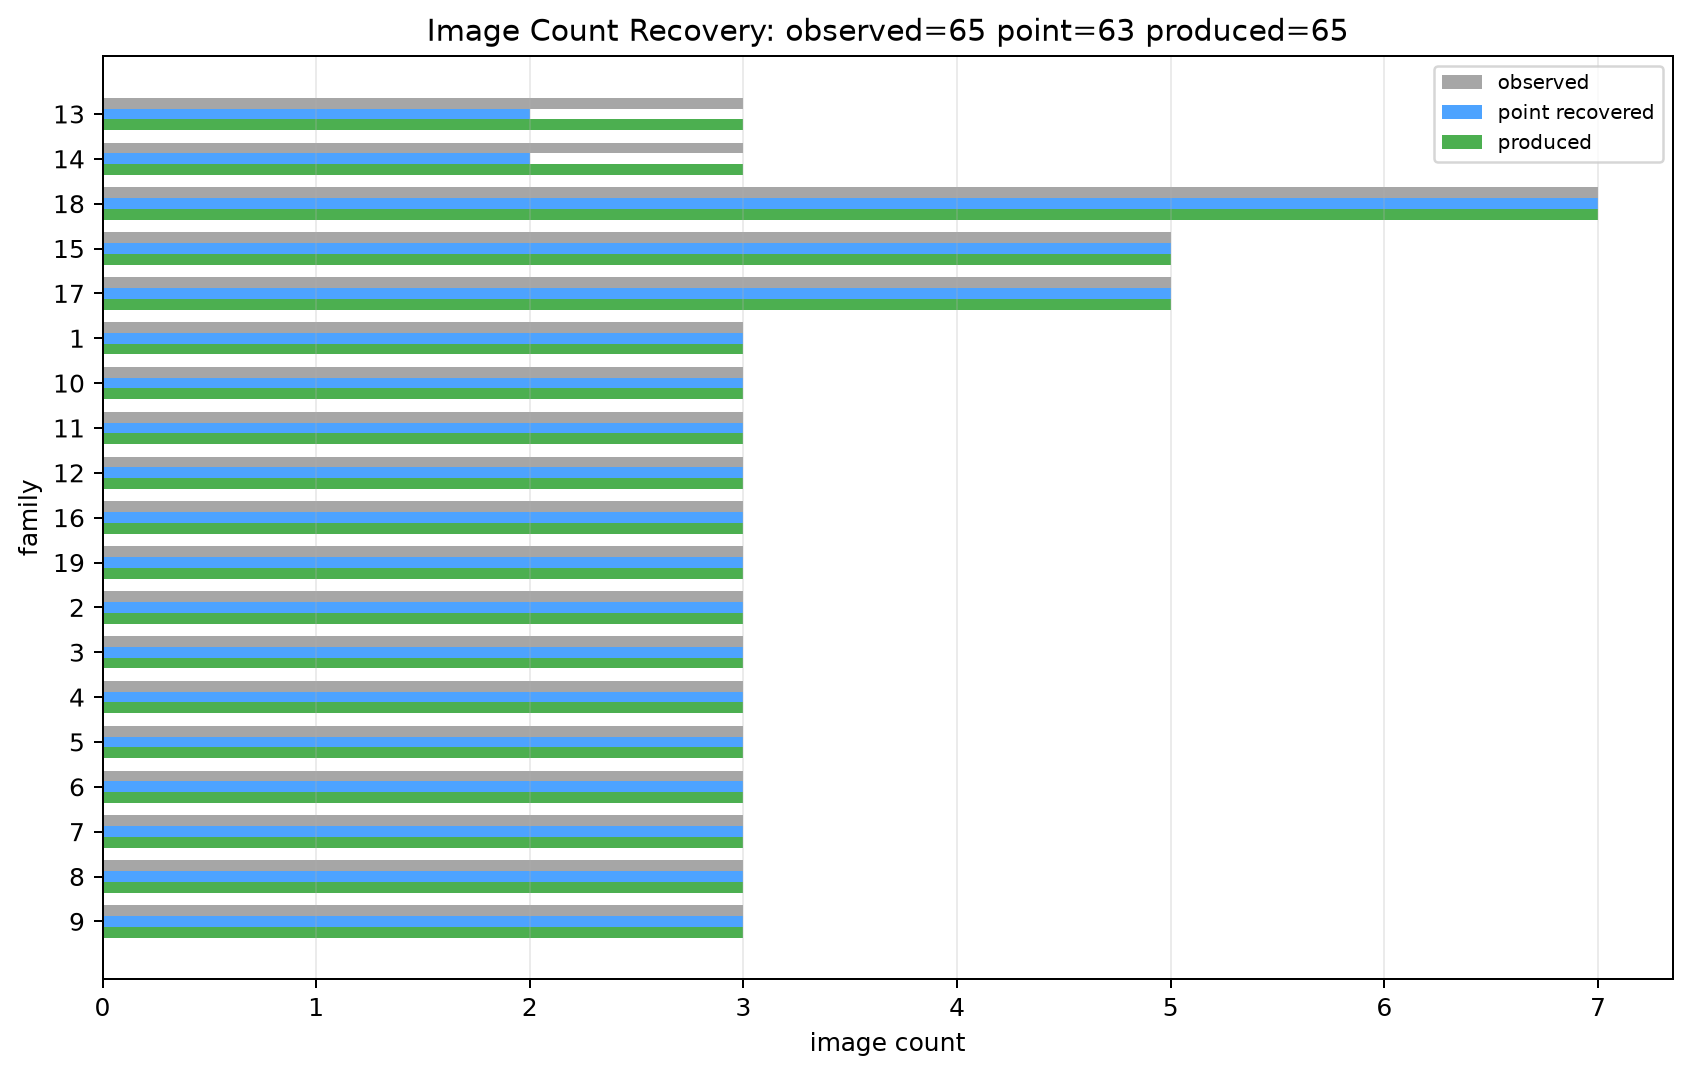

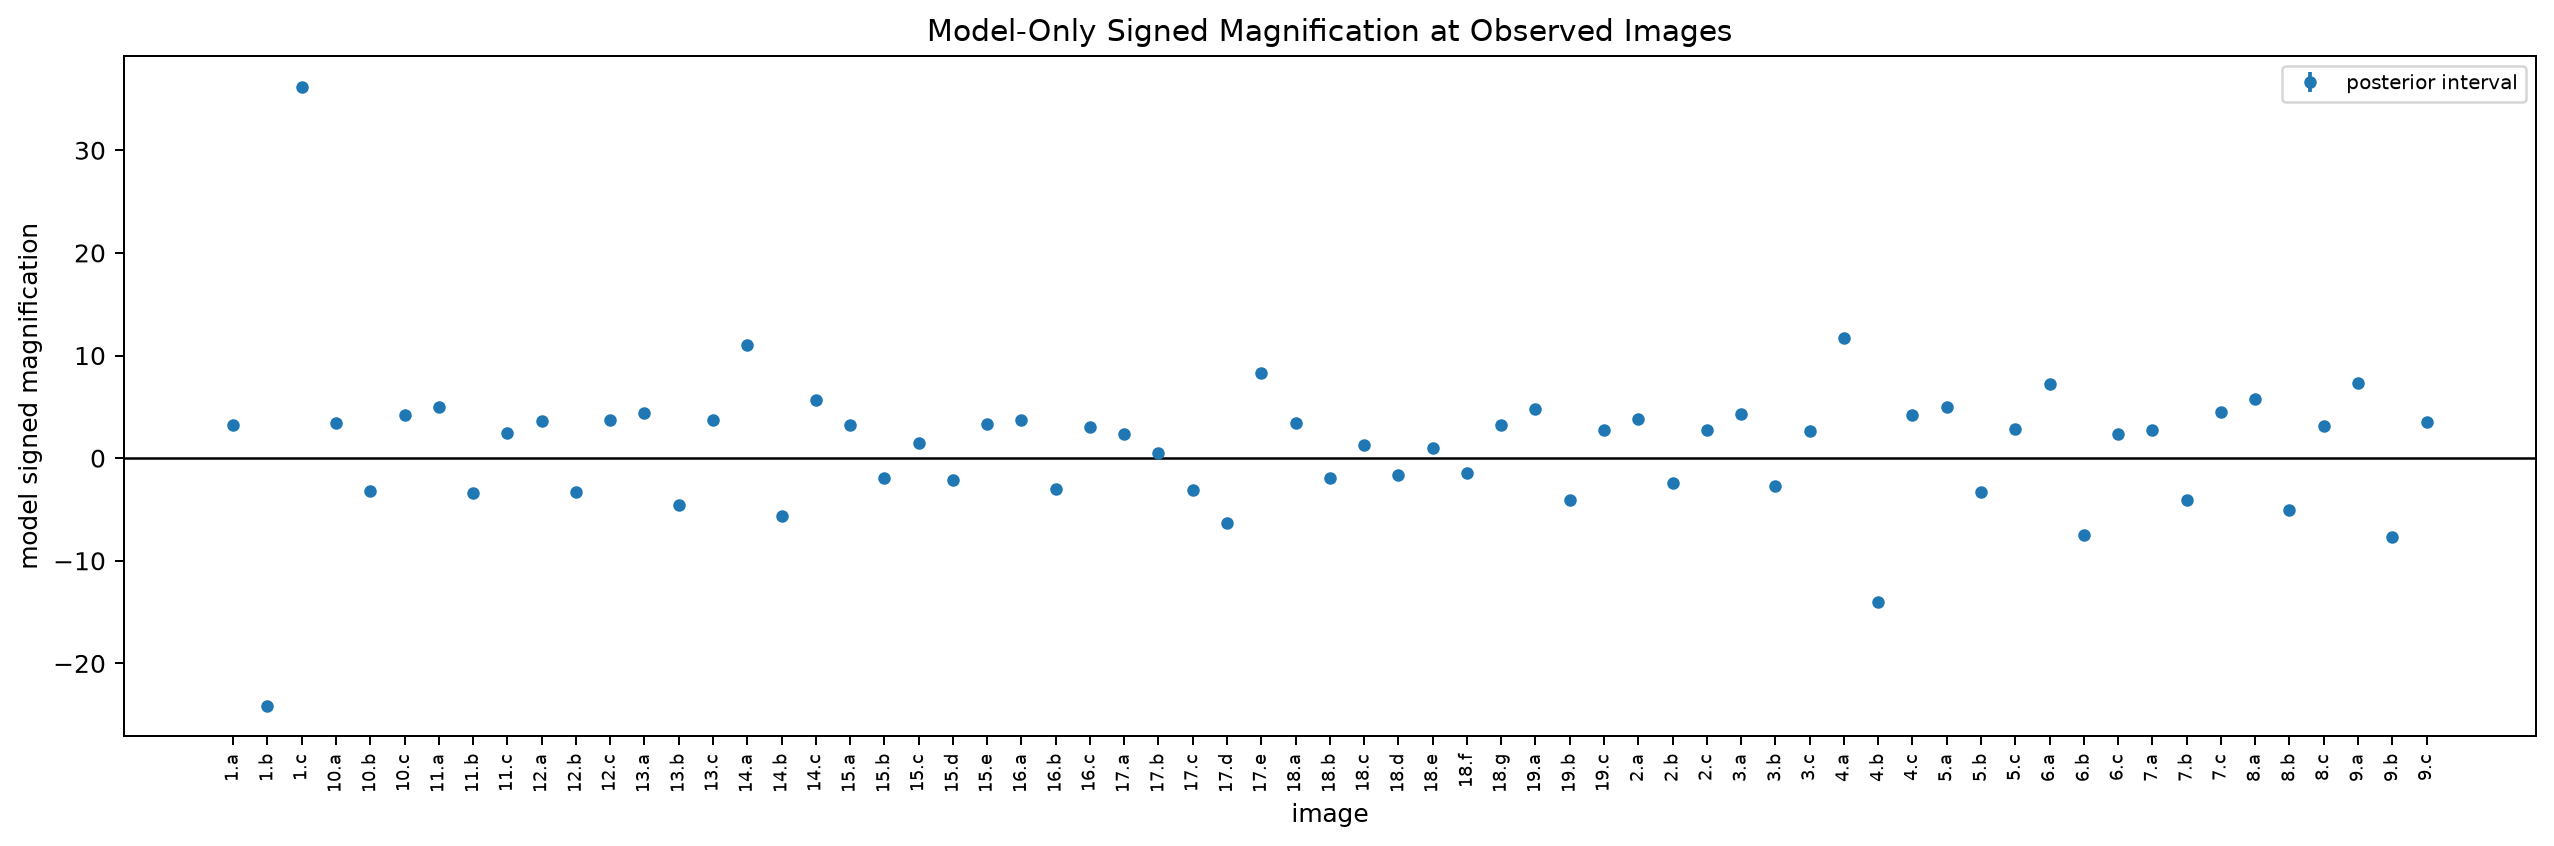

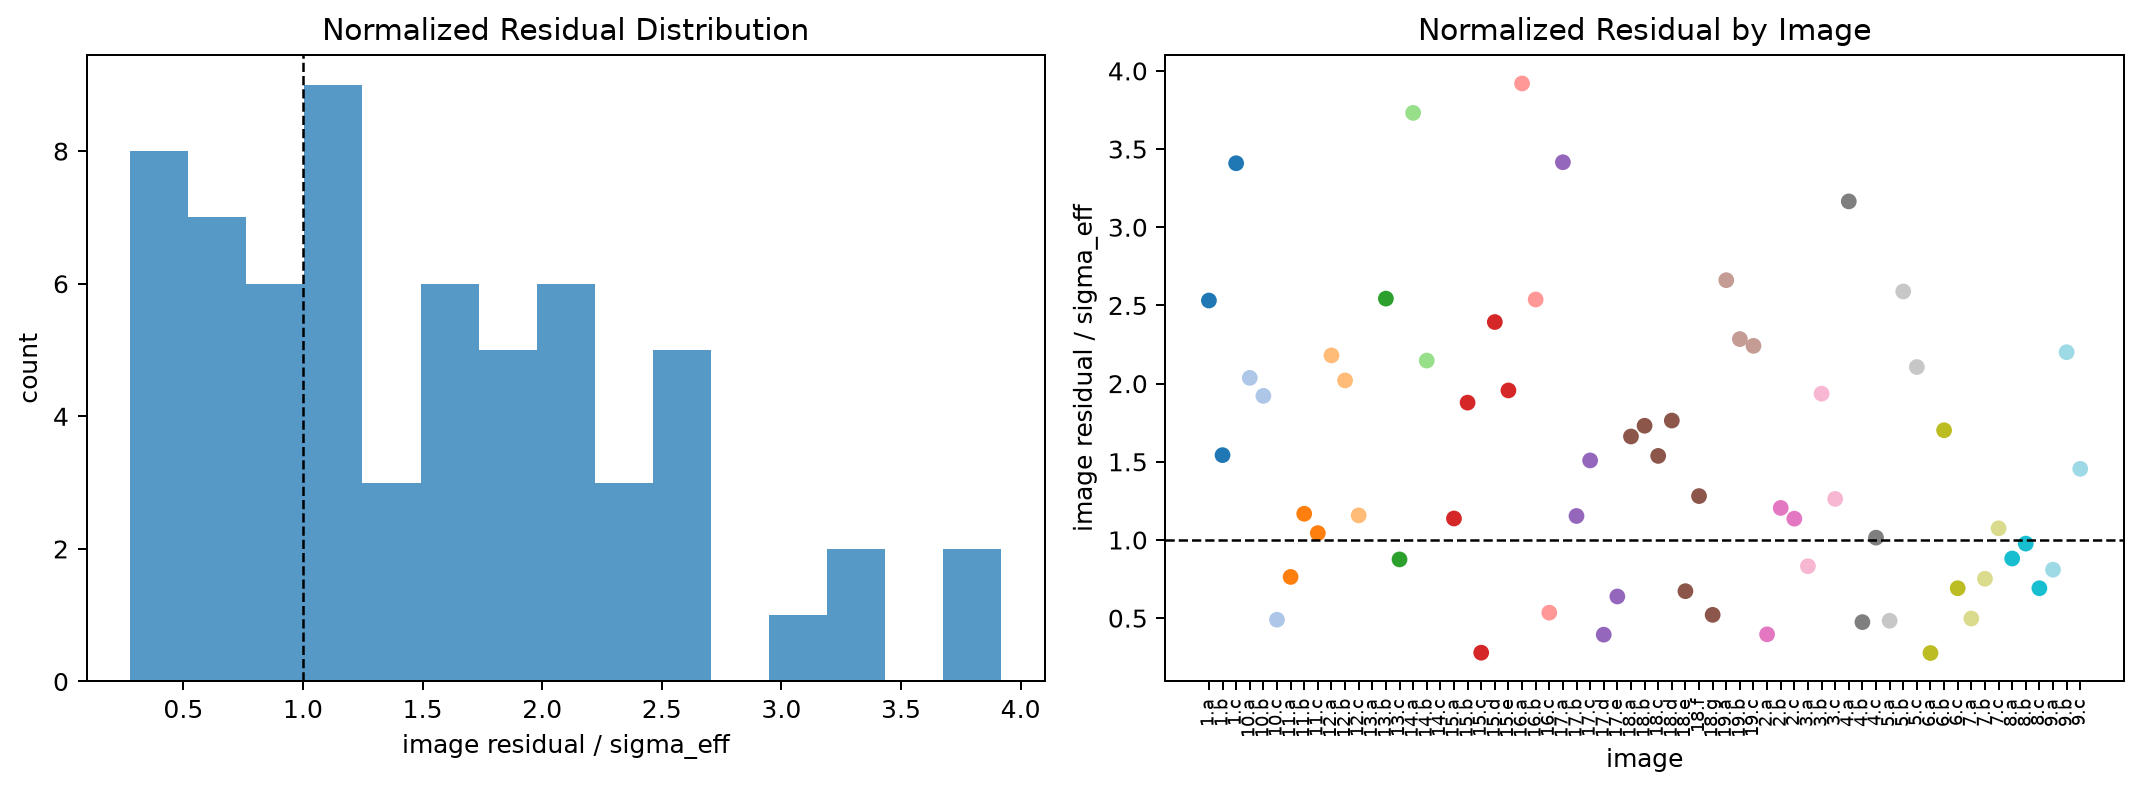

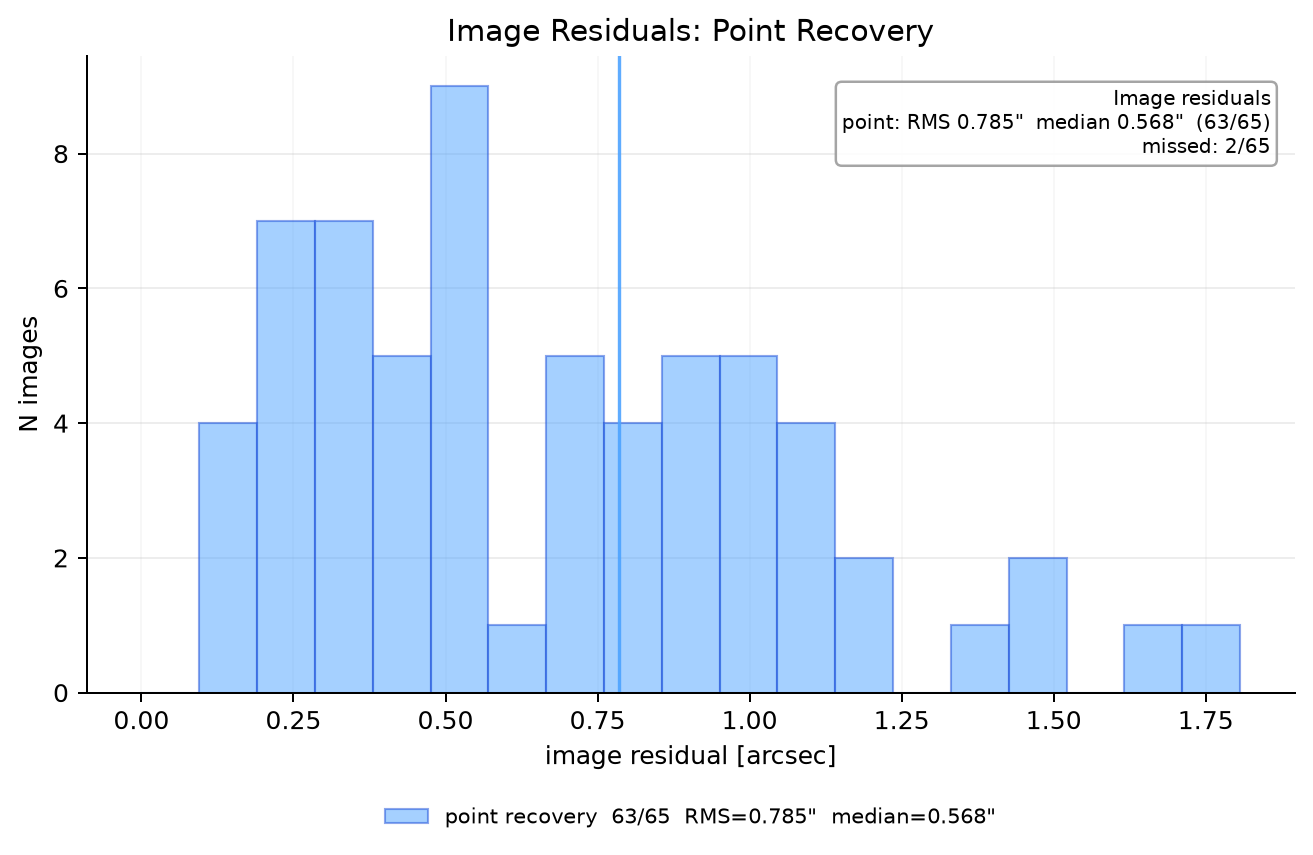

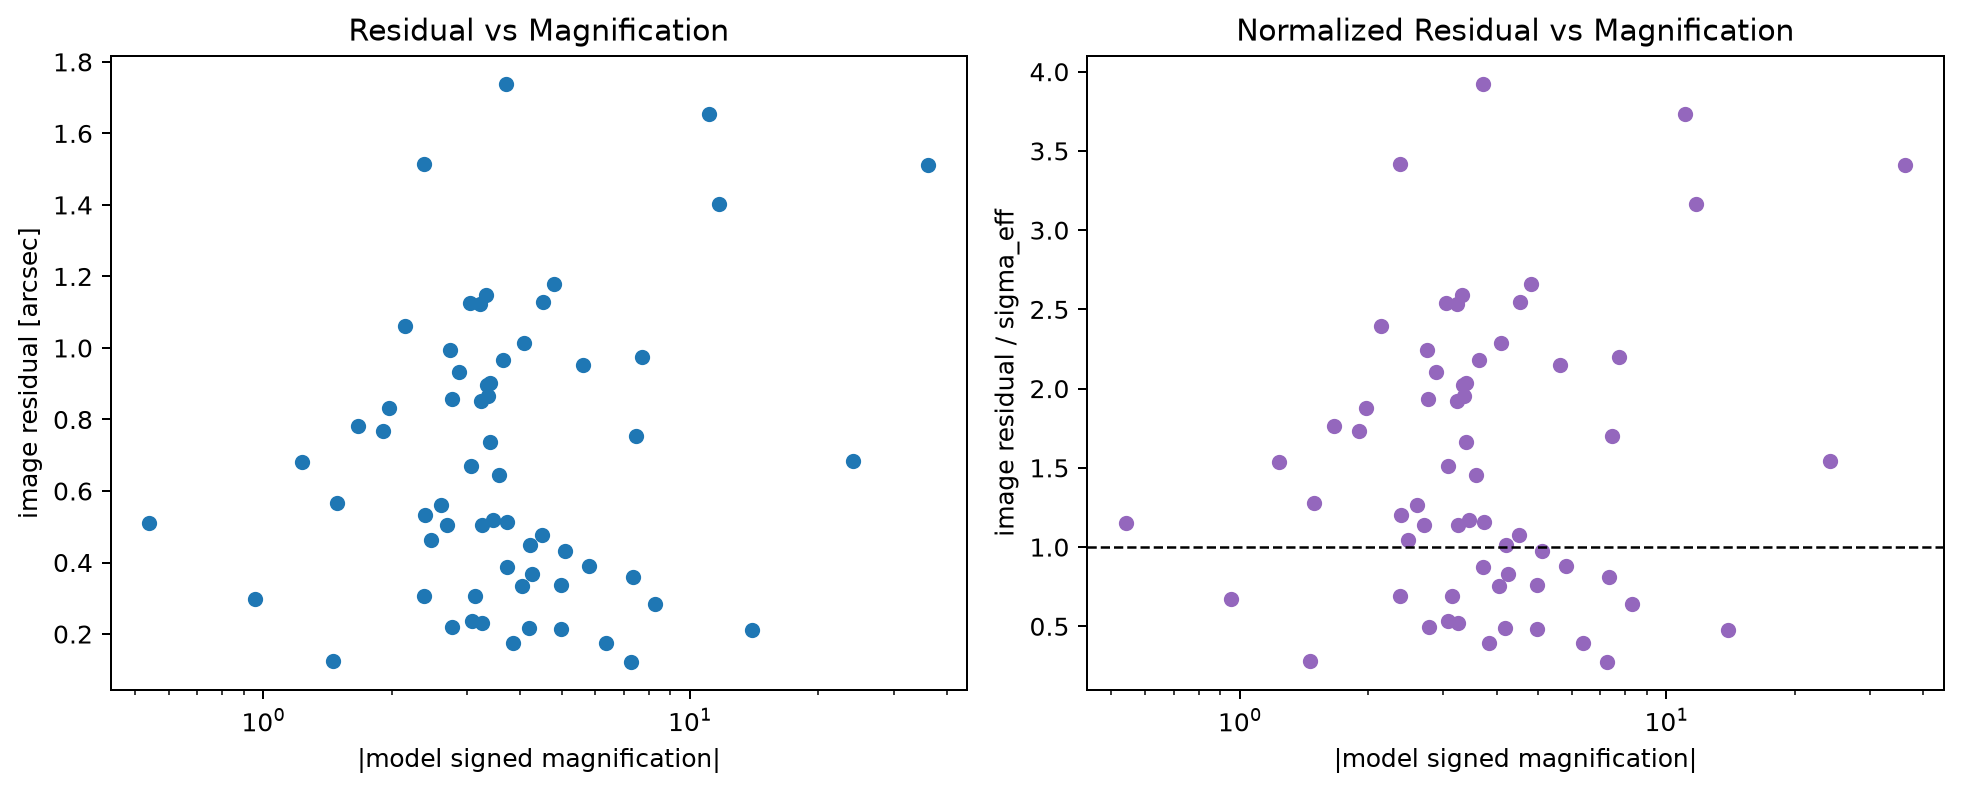

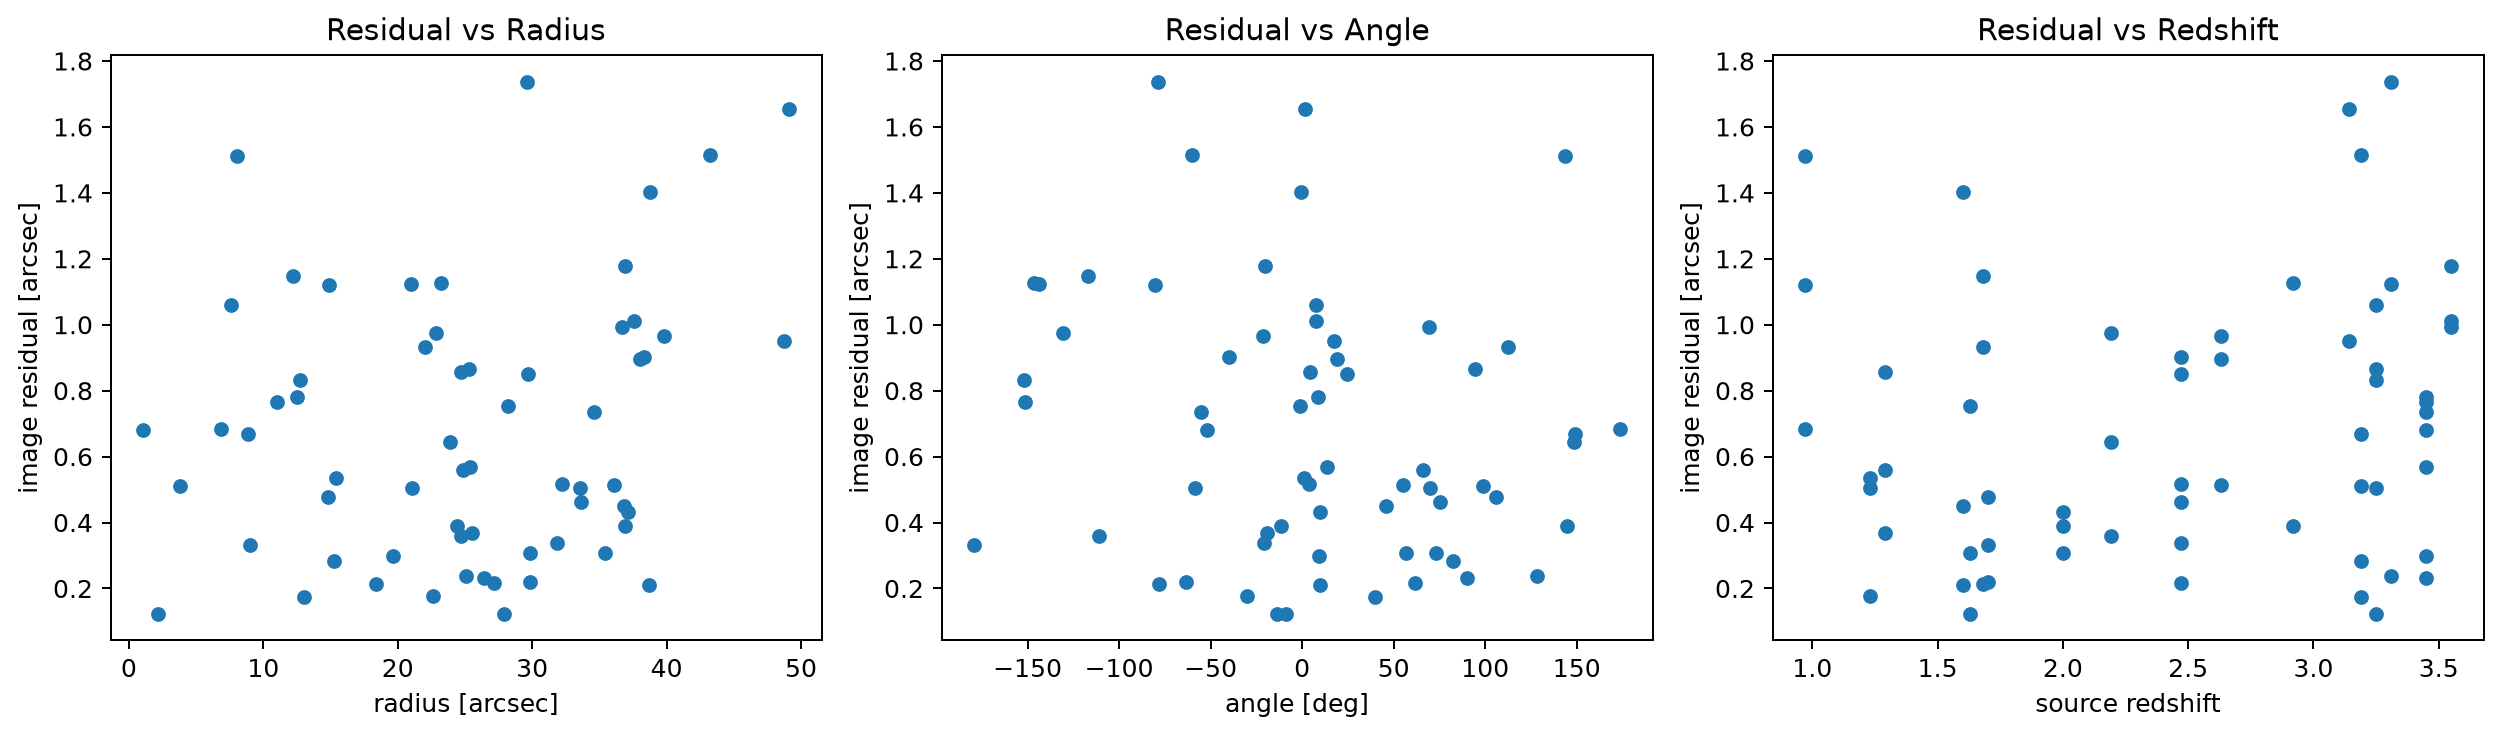

truth_recovery:   0%|          | 0/5 [00:00<?, ?it/s]

truth_recovery_grids: posterior draws:   0%|          | 0/16 [00:00<?, ?it/s]

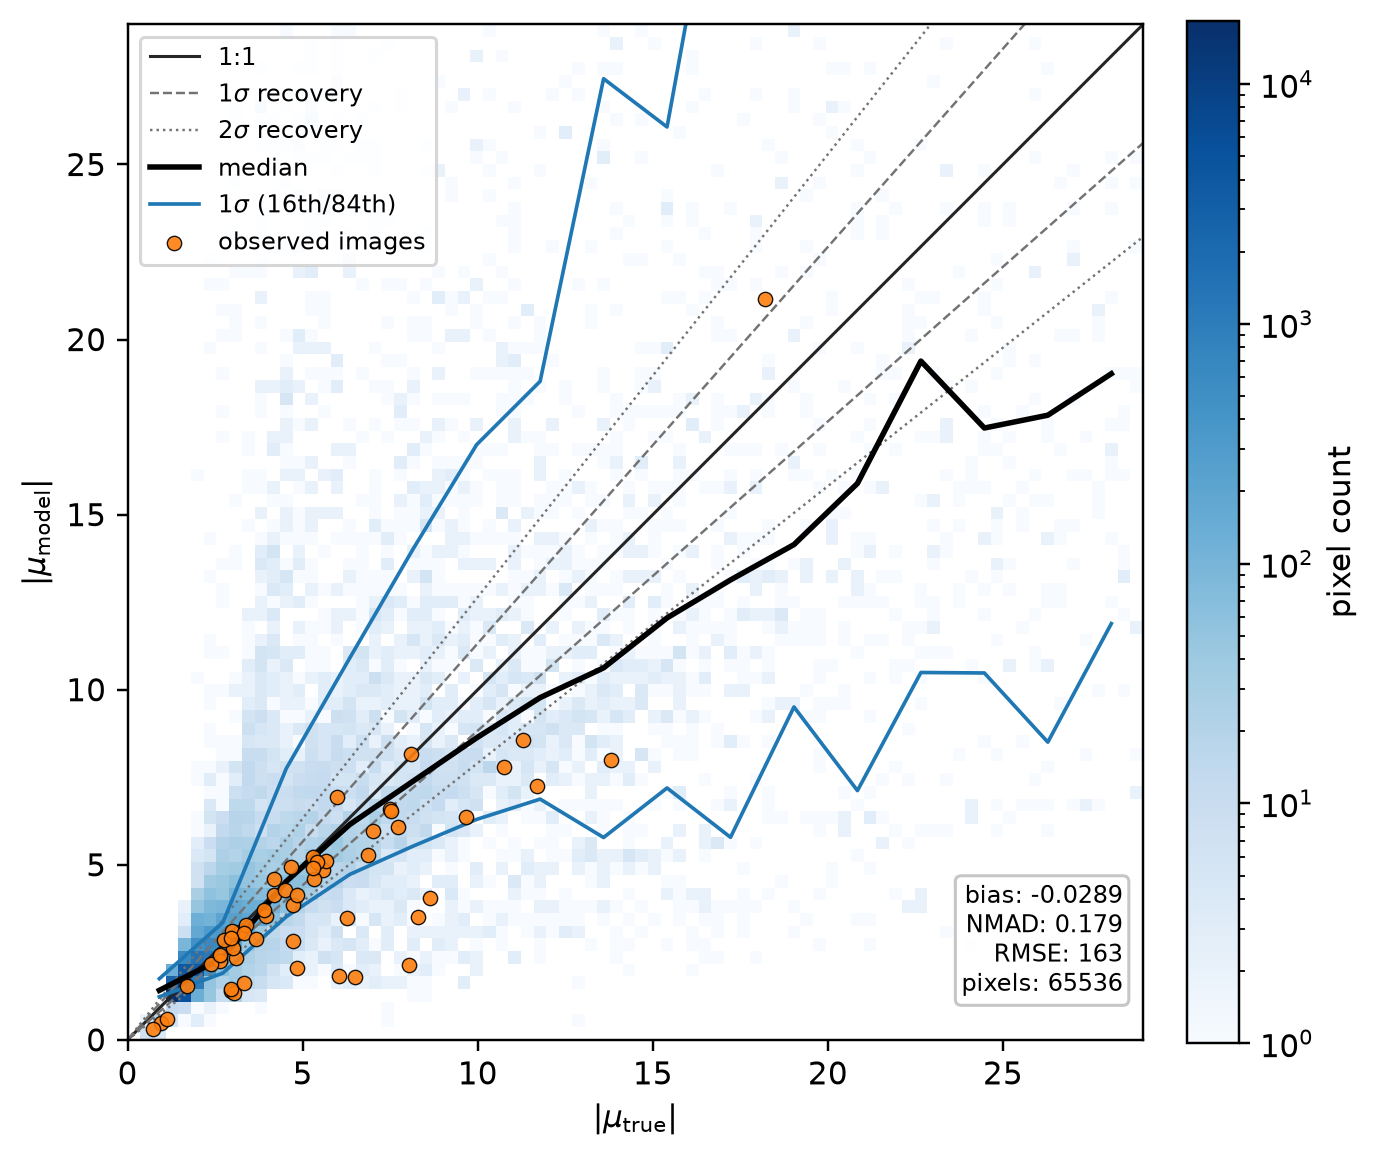

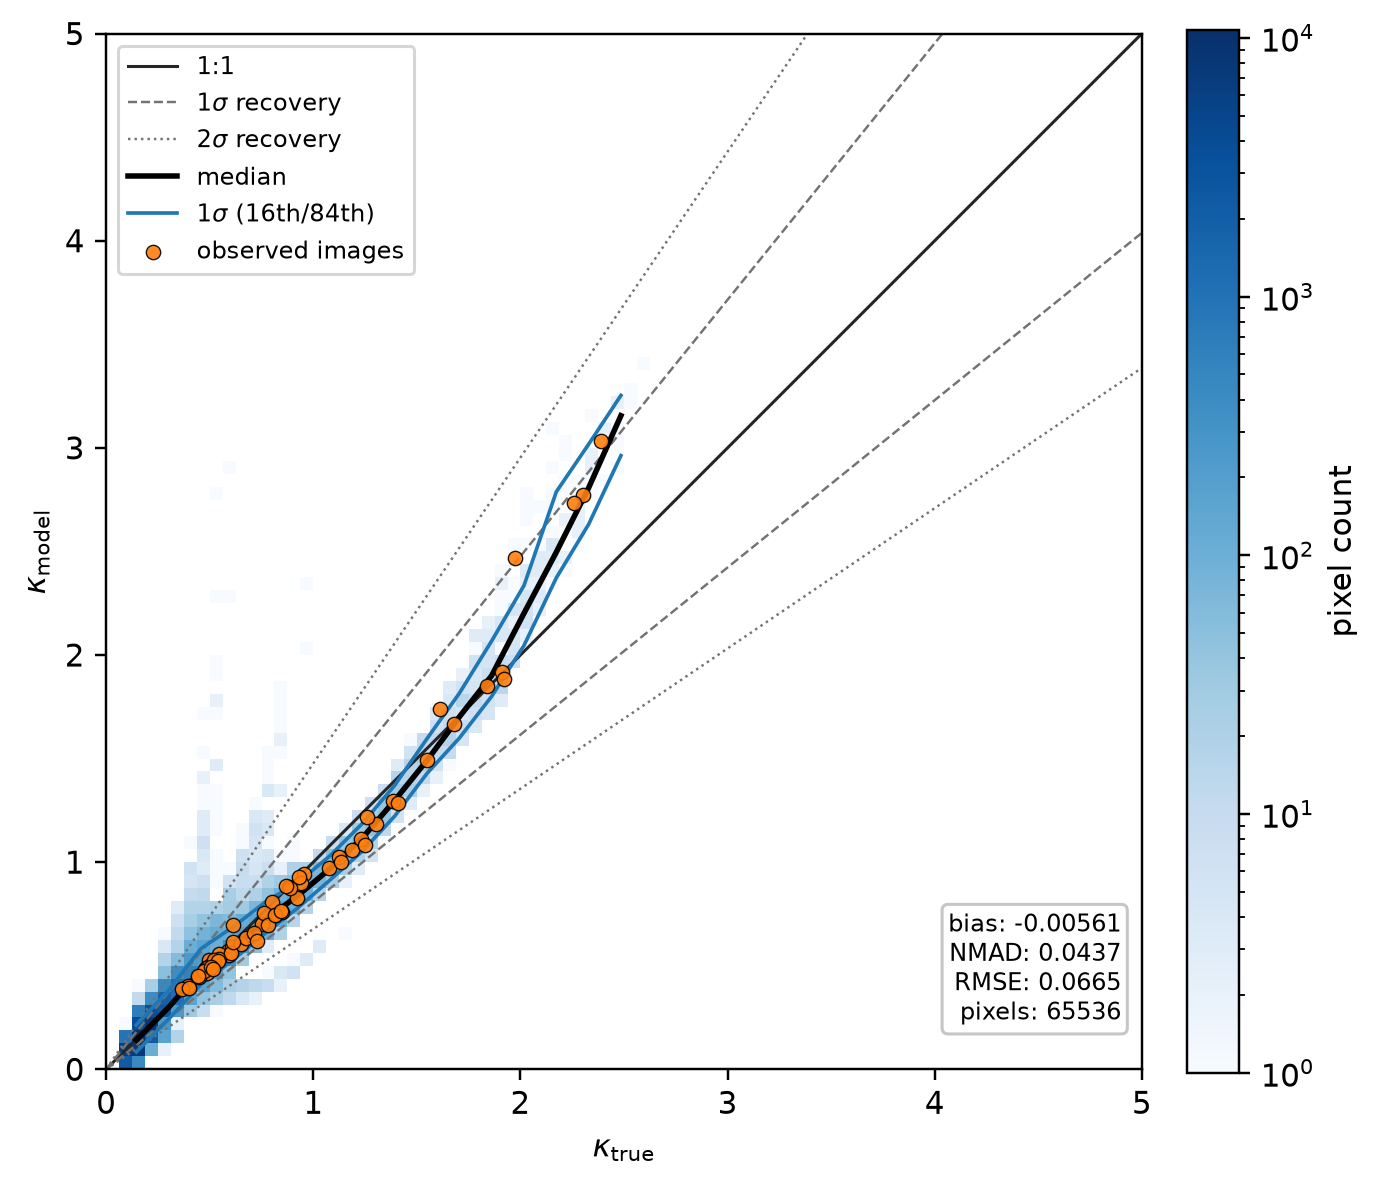

In [ ]:
from dataclasses import replace

# Regenerate validation tables/plots from saved parameter artifacts only.
# This does not rerun SVI/NUTS; it loads artifacts/plot_bundle.h5 and uses the standard plotting API.
validation_run_dir = result.run_dir if "result" in globals() else plan.output.output_dir / plan.output.run_name
artifact_paths = sorted(validation_run_dir.glob("**/artifacts/plot_bundle.h5"))
if not artifact_paths:
    raise FileNotFoundError(
        f"No saved plot_bundle.h5 artifacts found under {validation_run_dir}. "
        "Run the fit cell first, or set validation_run_dir to an existing completed run directory."
    )

validation_config = replace(
    config,
    paths=replace(
        config.paths,
        output_dir=validation_run_dir.parent,
        run_name=validation_run_dir.name,
    ),
    runtime=replace(
        config.runtime,
        plots_only=True,
        resume=True,
        skip_plots=False,
        quick_diagnostics=False,
        plot_numpyro_model=False,
        display_plots_in_notebook=True,
    ),
)
validation_plan = compile_run_plan(validation_config)
validation_result = LensClusterRunner().run(validation_plan)
validation_result

